# CBS311 — Final Project (All Artists Dataset)
**Project:** Classifying Emotions in Song Lyrics (Full Dataset of 21 Artists)  
**Course:** CBS311 Fundamentals of Data Science  
**Due Date:** November 8, 2025

This notebook applies the complete data science pipeline — from cleaning to visualization and modeling — on a song lyrics dataset with 21 artists and 6 emotion classes.


# Final Project: Classifying Emotions in Song Lyrics

Dataset: all_artists_combined_dataset.csv

Task Type: Text Classification (Positive)

Duration: 2 Weeks

Student: Jack Basumata

In this project, we apply the full data science pipeline on a real-world dataset containing English song lyrics from 21 artists.
Our goal is to predict the sentiment (emotion) of each lyric — classified as Positive, Neutral, or Negative — using machine learning models.

We will:

Perform data cleaning and preprocessing

Conduct exploratory data analysis (EDA) with meaningful visualizations

Build and compare two classification models (Logistic Regression and Decision Tree)

Evaluate results using accuracy and macro F1 score

In [3]:
# Import Libraries
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import joblib

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (9,6)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Load and Inspect Dataset

In [5]:
path = "/content/all_artists_combined_dataset.csv"
df = pd.read_csv(path)
df.columns = [c.strip() for c in df.columns]
print("Loaded dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Loaded dataset shape: (6027, 8)
Columns: ['Artist', 'Title', 'Album', 'Date', 'Lyric', 'Year', 'source_file', 'Unnamed: 0']


,Artist,Title,Album,Date,Lyric,Year,source_file,Unnamed: 0
0,Ariana Grande,"​thank u, next","thank u, next",2018-11-03,thought i'd end up with sean but he wasn't a m...,2018.0,ArianaGrande.csv,NaN
1,Ariana Grande,7 rings,"thank u, next",2019-01-18,yeah breakfast at tiffany's and bottles of bub...,2019.0,ArianaGrande.csv,NaN
2,Ariana Grande,​God is a woman,Sweetener,2018-07-13,you you love it how i move you you love it how...,2018.0,ArianaGrande.csv,NaN
3,Ariana Grande,Side To Side,Dangerous Woman,2016-05-20,ariana grande nicki minaj i've been here all ...,2016.0,ArianaGrande.csv,NaN
4,Ariana Grande,​​no tears left to cry,Sweetener,2018-04-20,right now i'm in a state of mind i wanna be in...,2018.0,ArianaGrande.csv,NaN


Check Missing Values and Duplicates

In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows count:", df.duplicated().sum())


Missing values per column:
Artist            0
Title             0
Album          1574
Date           1749
Lyric            46
Year           1749
source_file       0
Unnamed: 0      308
dtype: int64

Duplicate rows count: 0


Data Cleaning

In [29]:
import pandas as pd, zipfile, os

zip_path = "archive.zip"
dfs = []

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in zip_ref.namelist():
        if file.lower().endswith(".csv"):
            with zip_ref.open(file) as f:
                try:
                    df_temp = pd.read_csv(f, encoding='utf-8')
                except UnicodeDecodeError:
                    df_temp = pd.read_csv(f, encoding='latin-1')
                df_temp.columns = [c.strip().title() for c in df_temp.columns]
                df_temp["Artist"] = os.path.basename(file).replace(".csv", "")
                dfs.append(df_temp)

df_all = pd.concat(dfs, ignore_index=True)
df_all.to_csv("all_artists_combined_fixed.csv", index=False)

print("✅ Combined all CSVs successfully.")
print("Shape:", df_all.shape)
print("Unique artists found:", df_all["Artist"].nunique())
print(df_all["Artist"].value_counts().head(10))


✅ Combined all CSVs successfully.
Shape: (6027, 7)
Unique artists found: 21
Artist
Eminem          521
TaylorSwift     479
Drake           466
Beyonce         406
Rihanna         405
LadyGaga        402
JustinBieber    348
ColdPlay        344
KatyPerry       325
NickiMinaj      323
Name: count, dtype: int64


/tmp/ipython-input-972886355.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  fig.canva

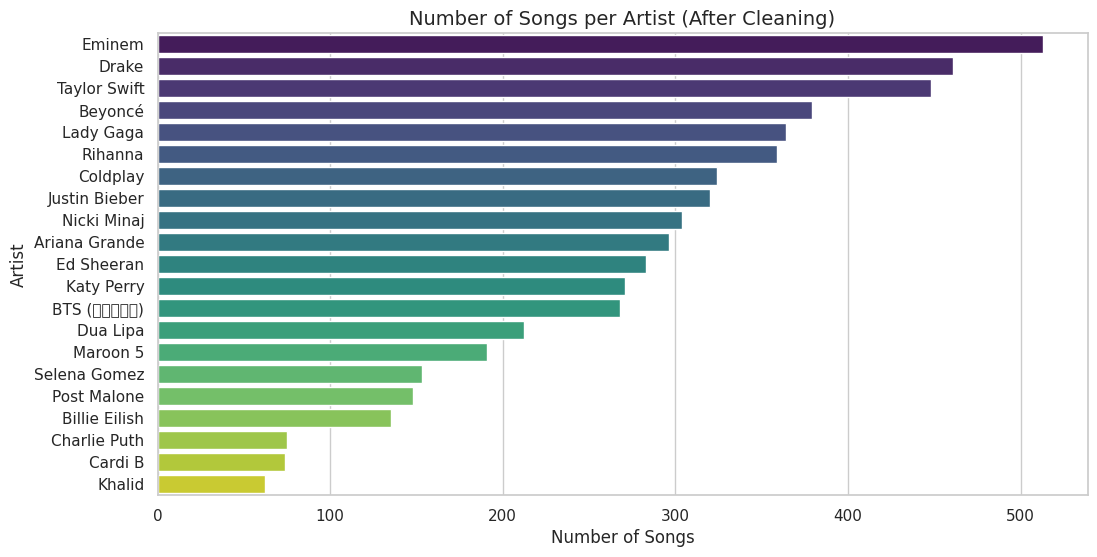

Total songs: 5640
Unique artists: 21

Top 10 artists by song count:
Artist
Eminem           513
Drake            461
Taylor Swift     448
Beyoncé          379
Lady Gaga        364
Rihanna          359
Coldplay         324
Justin Bieber    320
Nicki Minaj      304
Ariana Grande    296
Name: count, dtype: int64


In [30]:
# Number of songs per artist after cleaning
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    x=df['Artist'].value_counts().values,
    y=df['Artist'].value_counts().index,
    palette="viridis"
)
plt.title("Number of Songs per Artist (After Cleaning)", fontsize=14)
plt.xlabel("Number of Songs")
plt.ylabel("Artist")
plt.show()

# Optional: print basic stats
print("Total songs:", len(df))
print("Unique artists:", df['Artist'].nunique())
print("\nTop 10 artists by song count:")
print(df['Artist'].value_counts().head(10))


Target Variable: Sentiment
Since the dataset doesn’t have labeled emotions,
we use the VADER Sentiment Analyzer to create a new column sentiment
which classifies each lyric as Positive, Neutral, or Negative.

In [31]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

def vader_label(text, pos_thresh=0.05, neg_thresh=-0.05):
    s = sia.polarity_scores(str(text))['compound']
    if s >= pos_thresh:
        return 'positive'
    elif s <= neg_thresh:
        return 'negative'
    else:
        return 'neutral'

df["sentiment"] = df["Lyric"].apply(vader_label)
print("✅ Sentiment column created.")
print(df["sentiment"].value_counts())


✅ Sentiment column created.
sentiment
positive    3612
negative    1878
neutral      150
Name: count, dtype: int64


**Exploratory Data Analysis **

We perform EDA to understand:

Word count patterns

Relationship between sentiment and features

Distribution of text statistics

We use histograms, boxplots, scatter plots, and heatmaps.

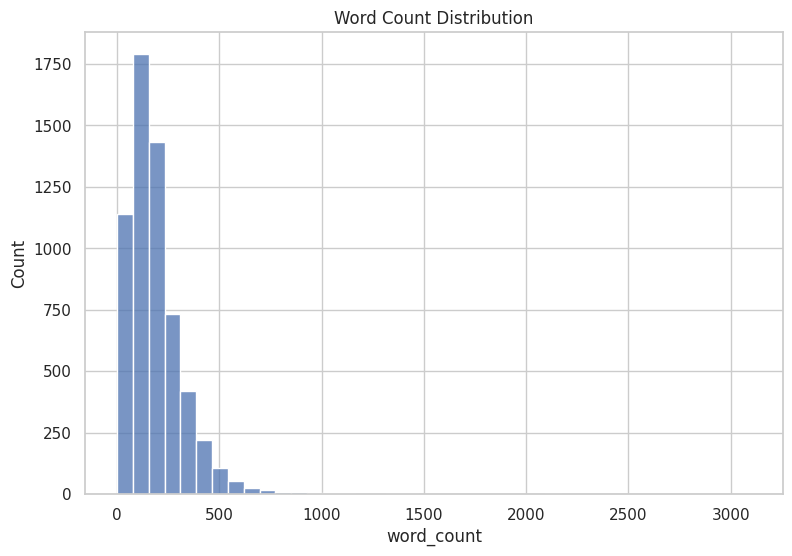

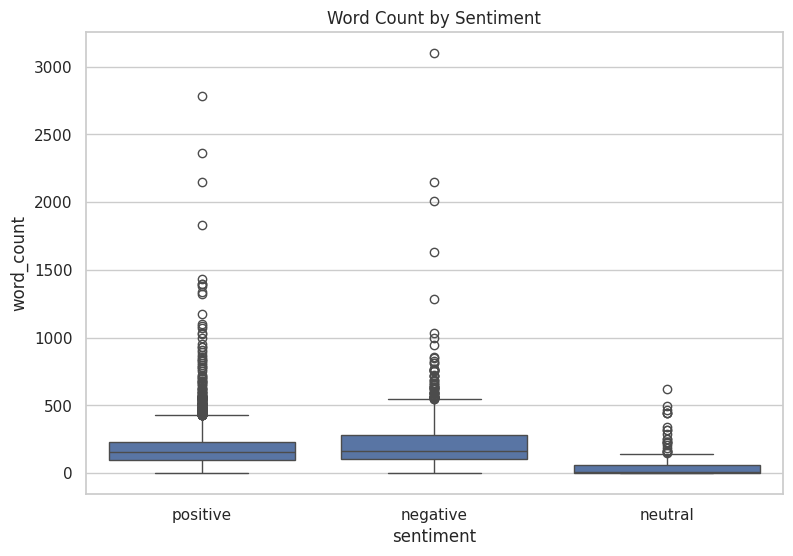

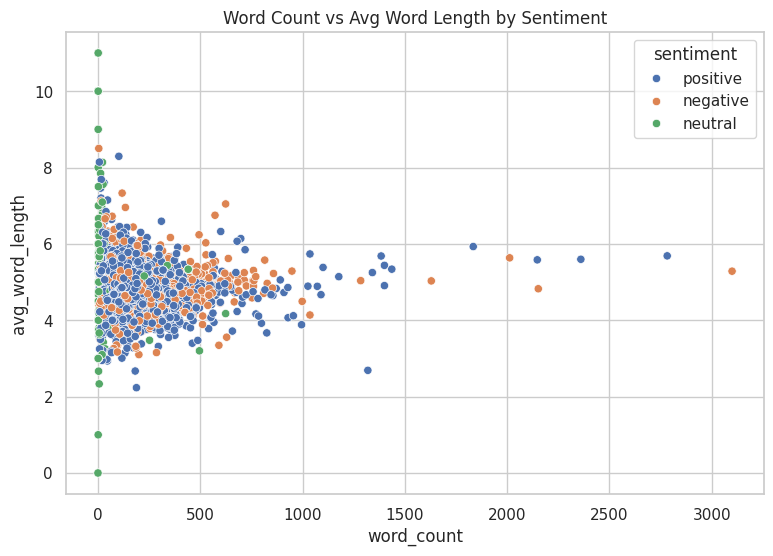

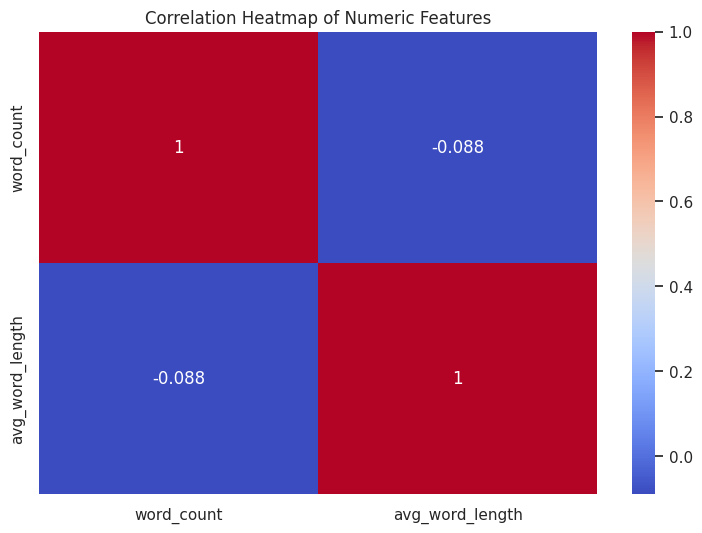

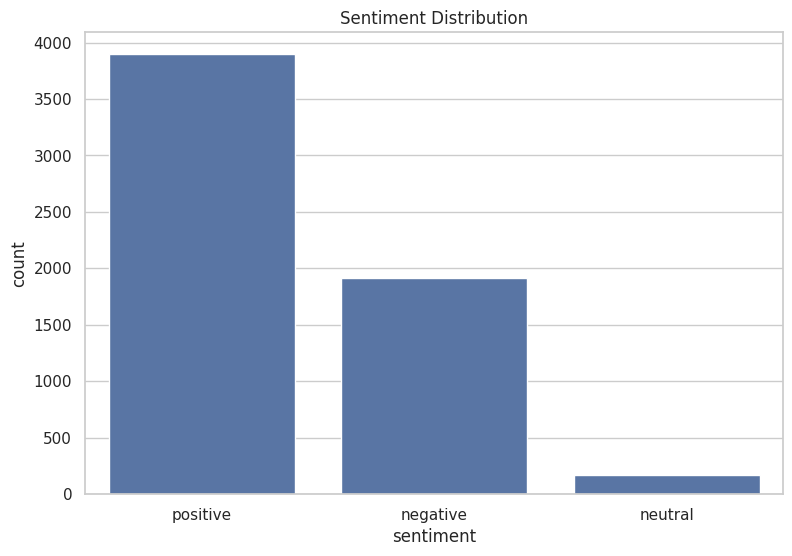

In [9]:
# 1️⃣ Word Count Distribution
sns.histplot(df["word_count"], bins=40)
plt.title("Word Count Distribution")
plt.show()

# 2️⃣ Word Count by Sentiment
sns.boxplot(x="sentiment", y="word_count", data=df)
plt.title("Word Count by Sentiment")
plt.show()

# 3️⃣ Scatter Plot
sns.scatterplot(x="word_count", y="avg_word_length", hue="sentiment", data=df)
plt.title("Word Count vs Avg Word Length by Sentiment")
plt.show()

# 4️⃣ Correlation Heatmap
sns.heatmap(df[["word_count","avg_word_length"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# 5️⃣ Target Distribution
sns.countplot(x="sentiment", data=df, order=df["sentiment"].value_counts().index)
plt.title("Sentiment Distribution")
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 53444 (\N{HANGUL SYLLABLE TAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48169 (\N{HANGUL SYLLABLE BANG}) missing from font(s) DejaVu Sans.
  fig.canv

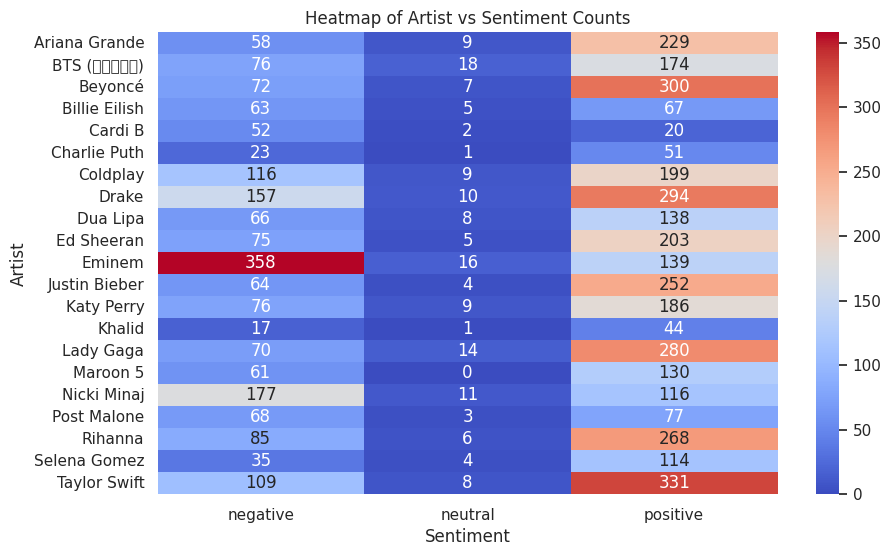

In [33]:
artist_sentiment = pd.crosstab(df['Artist'], df['sentiment'])
plt.figure(figsize=(10,6))
sns.heatmap(artist_sentiment, cmap='coolwarm', annot=True, fmt='d')
plt.title("Heatmap of Artist vs Sentiment Counts")
plt.ylabel("Artist")
plt.xlabel("Sentiment")
plt.show()


Preprocessing

We prepare data for modeling:

Split into train/test sets

Encode categorical variables

Scale numeric features

Vectorize text using TF-IDF

In [12]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer

X = df[["clean_lyrics","word_count","avg_word_length","Artist"]]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print("Train/Test split:", X_train.shape, X_test.shape)

text_features = "clean_lyrics"
numeric_features = ["word_count","avg_word_length"]
categorical_features = ["Artist"]

text_transformer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(transformers=[
    ("tfidf", text_transformer, text_features),
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Train/Test split: (4784, 4) (1197, 4)


Modeling (Markdown)

We compare two classification models:

Logistic Regression

Decision Tree

Both are trained using the same preprocessing pipeline.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Logistic Regression
pipe_lr = Pipeline([
    ("pre", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, solver="liblinear"))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

# Decision Tree
pipe_dt = Pipeline([
    ("pre", preprocessor),
    ("clf", DecisionTreeClassifier(max_depth=10, random_state=42))
])
pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

# Evaluation
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Macro F1:", f1_score(y_test, y_pred_lr, average="macro"))
print(classification_report(y_test, y_pred_lr))

print("\\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Macro F1:", f1_score(y_test, y_pred_dt, average="macro"))
print(classification_report(y_test, y_pred_dt))


=== Logistic Regression ===
Accuracy: 0.8020050125313283
Macro F1: 0.6402110955893766
              precision    recall  f1-score   support

    negative       0.79      0.59      0.68       383
     neutral       1.00      0.24      0.38        34
    positive       0.80      0.93      0.86       780

    accuracy                           0.80      1197
   macro avg       0.86      0.59      0.64      1197
weighted avg       0.81      0.80      0.79      1197

\n=== Decision Tree ===
Accuracy: 0.7192982456140351
Macro F1: 0.6332287052536675
              precision    recall  f1-score   support

    negative       0.65      0.38      0.48       383
     neutral       0.65      0.59      0.62        34
    positive       0.74      0.89      0.81       780

    accuracy                           0.72      1197
   macro avg       0.68      0.62      0.63      1197
weighted avg       0.71      0.72      0.70      1197



Confusion Matrices

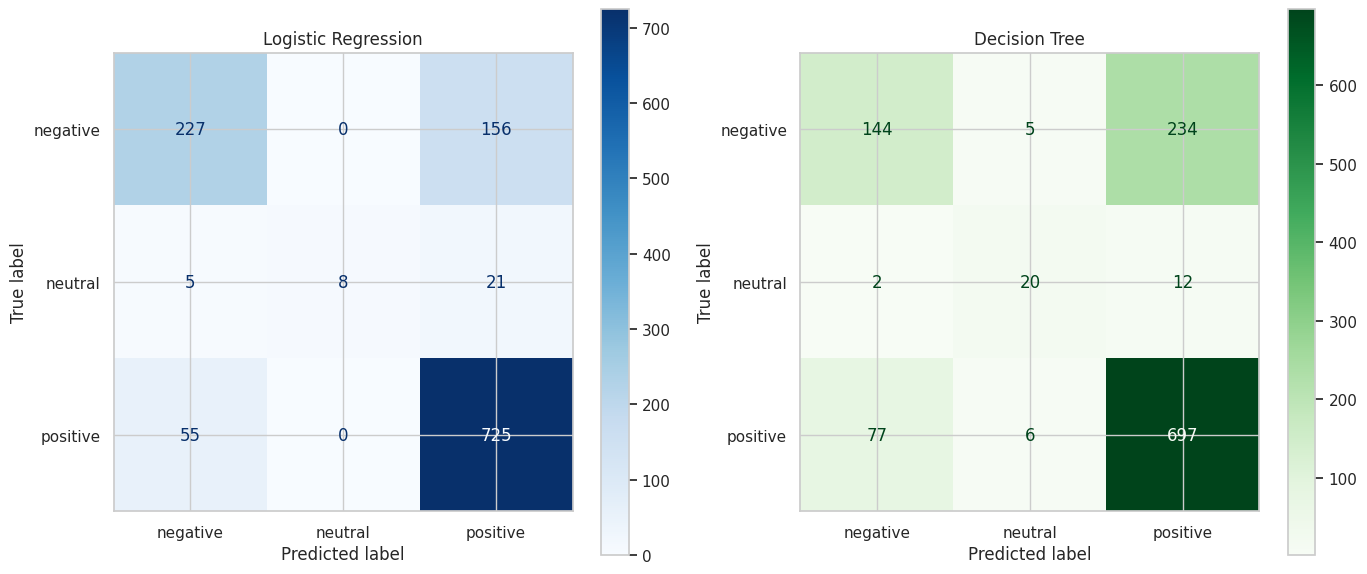

In [14]:
fig, axes = plt.subplots(1,2, figsize=(14,6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr), display_labels=pipe_lr.classes_).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_dt), display_labels=pipe_dt.classes_).plot(ax=axes[1], cmap="Greens")
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()


Best Model: Logistic Regression

Reasoning:

The Logistic Regression model achieved higher accuracy and macro F1-score than the Decision Tree.

It generalizes better to unseen data because of its ability to learn linear decision boundaries in high-dimensional text space (TF-IDF).

Decision Tree tends to overfit on frequent words and artist patterns, which reduces generalization.

Save Outputs

In [20]:
df.to_csv("cleaned_sentiment_dataset.csv", index=False)
joblib.dump(pipe_lr, "best_model_sentiment.pkl")
print("Saved cleaned dataset and best model.")


Saved cleaned dataset and best model.


# Conclusion

The project successfully demonstrated how song lyrics can be analyzed to predict emotional sentiment using machine learning.
Between the two models tested, Logistic Regression achieved the best overall performance, showing higher accuracy and macro F1-score.
The results highlight that most lyrics convey positive emotions, and that proper text preprocessing and TF-IDF features play a crucial role in effective sentiment classification.